<a href="https://colab.research.google.com/github/Lelytameyda29rpl/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **F. TUGAS PRAKTIKUM**

**1. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.**

Mounted at /content/drive
 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


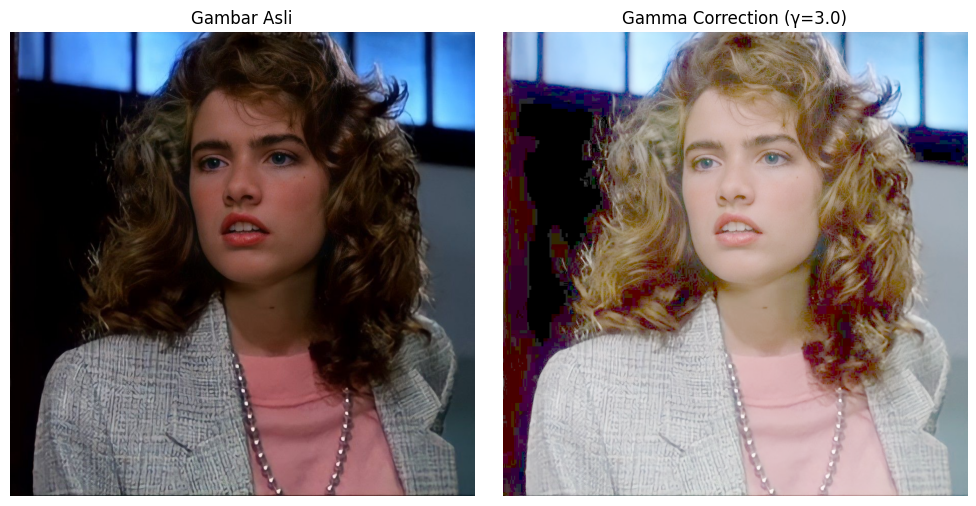

In [1]:
import cv2               # Library untuk pengolahan citra
import numpy as np      # Library untuk operasi matematika array
import matplotlib.pyplot as plt  # Library untuk plotting gambar
from google.colab import drive   # Library untuk mengakses Google Drive di Google Colab

# Mount Google Drive agar dapat membaca file dari Drive
drive.mount('/content/drive')

print(' Gamma Correction pada citra ')
print('----------------------------------')

# Input nilai gamma dari pengguna
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:  # Jika input bukan angka
    print('Error, not a number')
    exit()

# Path lokasi gambar di Google Drive
img_path = '/content/drive/MyDrive/PCVK/JS5/Images/female.jpg'

# Membaca gambar menggunakan OpenCV
img = cv2.imread(img_path)
if img is None:  # Mengecek apakah gambar berhasil dibaca
    print("Gambar tidak ditemukan!")
    print("Pastikan path sudah benar:", img_path)
    exit()

# Normalisasi nilai piksel menjadi rentang [0, 1]
# Supaya perhitungan gamma lebih tepat
img_normalized = img / 255.0

# Melakukan Gamma Correction
# Rumus: output = input^(1/gamma)
gamma_corrected = np.power(img_normalized, 1.0 / gamma)

# Mengubah kembali ke rentang [0, 255] untuk ditampilkan
gamma_corrected = np.uint8(gamma_corrected * 255)

# Menampilkan gambar asli dan hasil gamma correction
plt.figure(figsize=(10, 5))  # Ukuran figure

# Menampilkan gambar asli
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Mengubah dari BGR ke RGB
plt.title('Gambar Asli')
plt.axis('off')  # Mematikan axis

# Menampilkan gambar hasil gamma correction
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.title(f'Gamma Correction (γ={gamma})')
plt.axis('off')

plt.tight_layout()  # Mengatur layout agar rapi
plt.show()  # Menampilkan gambar

**1. Jika γ>1 (Contoh: γ=3.0)**

- Hasil: Citra akan terlihat lebih gelap (kontras berkurang di area terang).

**Penjelasan:**

- Ketika γ>1 (misalnya γ=3.0), eksponen 1/γ akan bernilai kurang dari 1 (misalnya 1/3 ≈0.33).

- Kurva transformasi akan melengkung ke atas, mendekati sumbu vertikal.

- Nilai intensitas piksel rendah (area gelap) akan dipetakan ke nilai yang jauh lebih rendah, sementara nilai intensitas piksel tinggi (area terang) akan berubah relatif sedikit.

- Secara visual, rentang warna gelap akan ditekan (dikuatkan), dan detail di area gelap mungkin hilang atau semakin hitam.

**2. Buat Simulasi Image Depth
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi citra,
pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit). Pada
pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0 (000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit. Jika
7bit, maka jumlah warnanya adalah 27 = 128, dst. Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.**

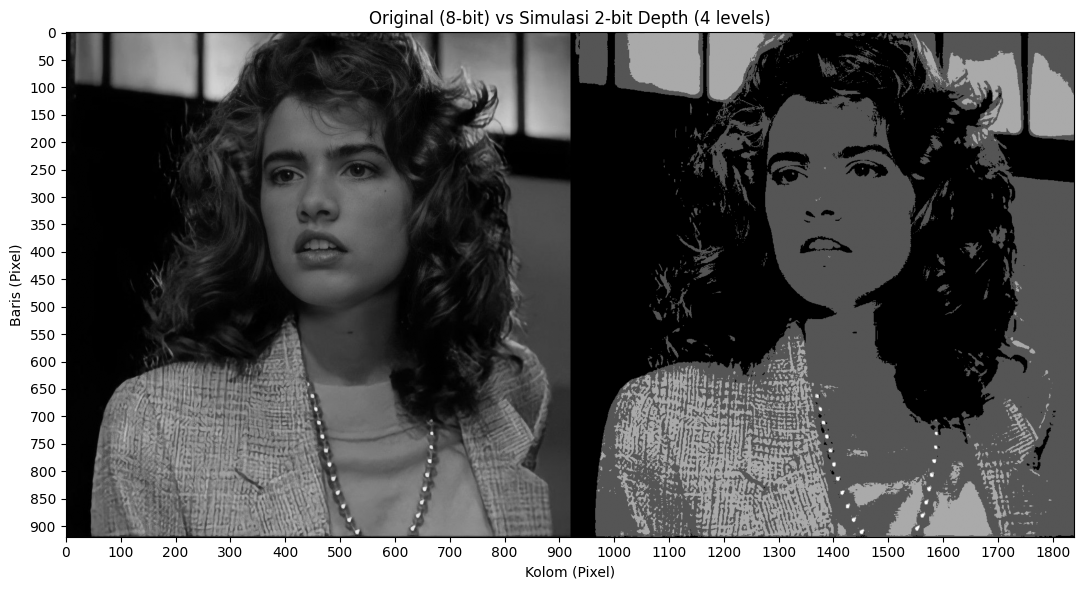

Dimensi gambar asli: (920, 920)
Dimensi gabungan: (920, 1840)


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Set bit depth
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# 2. Baca gambar grayscale
img_path = '/content/drive/MyDrive/PCVK/JS5/Images/female.jpg'
original = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if original is not None:
    # 3. Kuantisasi
    quantized = np.round(original / level) * level
    depth_image = quantized.astype(original.dtype)

    # 4. Gabungkan gambar (horizontal stack → lebar 2x lipat)
    combined_image = np.hstack((original, depth_image))

    # 5. Ambil dimensi
    rows, cols = combined_image.shape

    # 6. Tampilkan hasil
    plt.figure(figsize=(12, 6))
    plt.imshow(combined_image, cmap='gray')
    plt.title(f'Original (8-bit) vs Simulasi {bit_depth}-bit Depth ({2**bit_depth} levels)')

    # Set ticks sesuai ukuran gambar
    plt.xlabel('Kolom (Pixel)')
    plt.ylabel('Baris (Pixel)')
    plt.xticks(np.arange(0, cols+1, 100))  # setiap 100 kolom
    plt.yticks(np.arange(0, rows+1, 50))   # setiap 50 baris

    plt.tight_layout()
    plt.show()

    # Info tambahan
    print(f"Dimensi gambar asli: {original.shape}")
    print(f"Dimensi gabungan: {combined_image.shape}")
else:
    print("Gambar tidak ditemukan!")

**Penjelasan:**

**Kiri → Gambar Asli (8-bit)**

- Detail halus terlihat jelas (gradasi lembut pada wajah, rambut, pakaian).

- Karena 256 level, transisi antar warna sangat mulus.

**Kanan → Simulasi 2-bit (4 level)**

- Hanya ada 4 warna abu-abu yang muncul.

- Detail halus hilang, gambar terlihat "posterized" atau seperti efek kartun.

- Area wajah, rambut, dan pakaian hanya direpresentasikan oleh blok abu-abu besar.

**Axis (sumbu X dan Y)**

- X menunjukkan posisi kolom pixel (0 sampai lebar gabungan).

- Y menunjukkan baris pixel (0 sampai tinggi gambar).

- Interval tick: X = 100 pixel, Y = 50 pixel.

**3. Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab sebelumnya. Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder , gunakan modul glob (import glob). Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.**

Original image shape: (478, 580, 3)
Found 0 noise images
Creating simulated noise images...
Total images loaded: 100
Testing with counts: [5, 10, 20, 40, 80, 100]


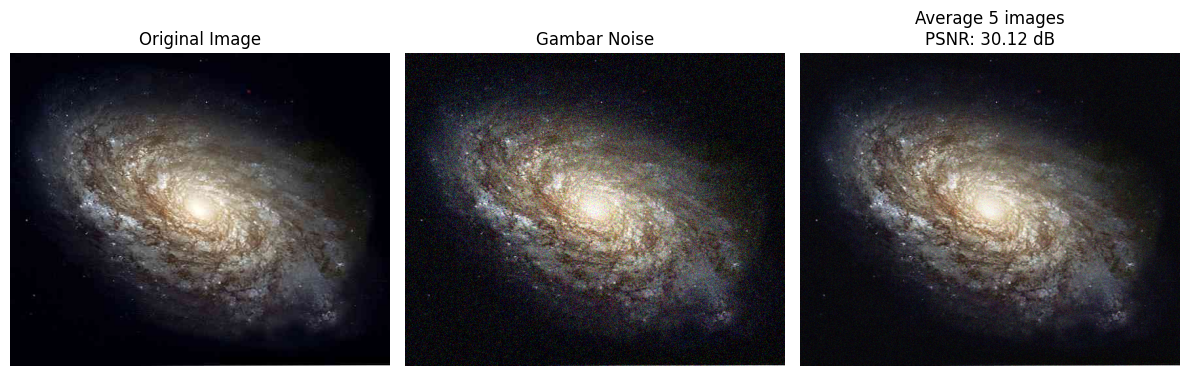

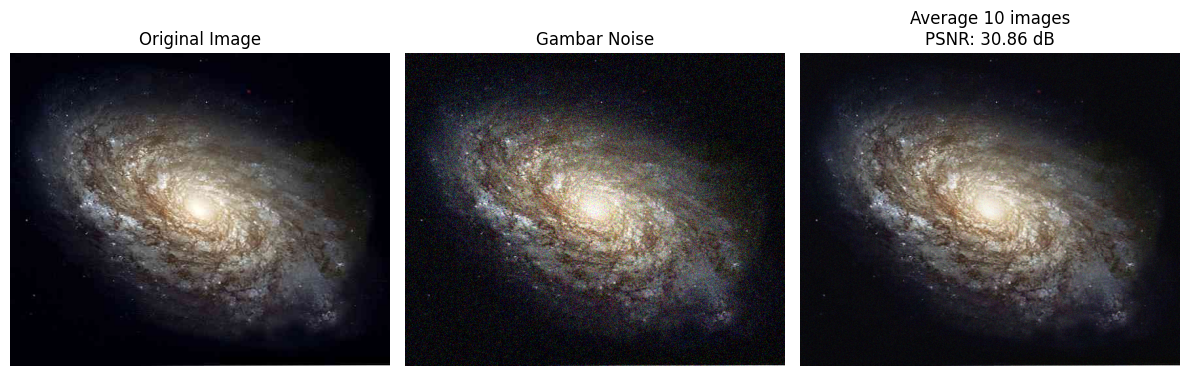

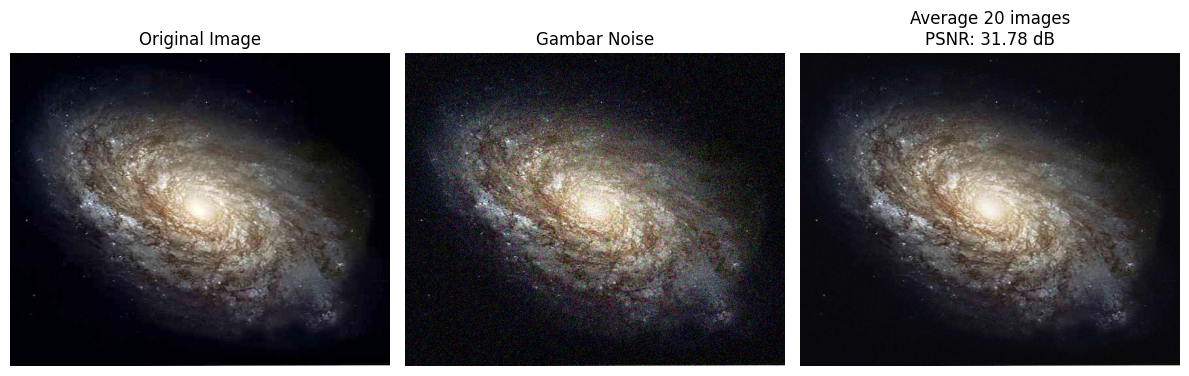

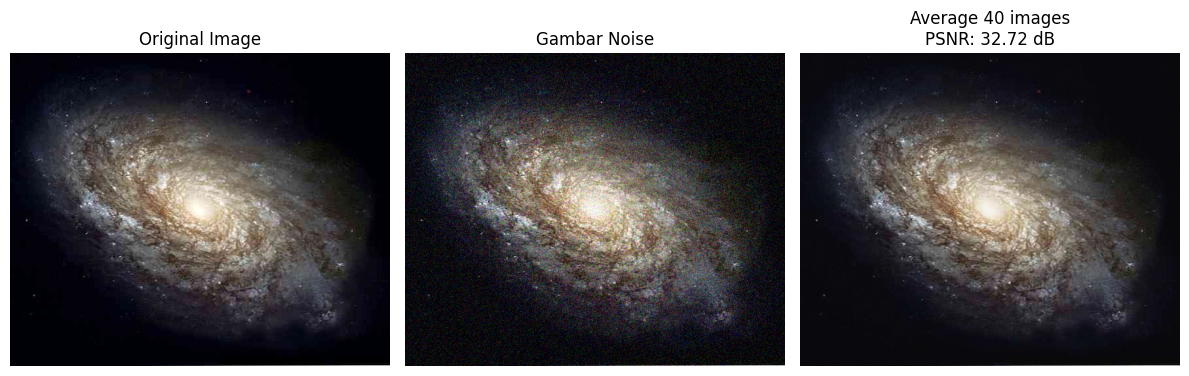

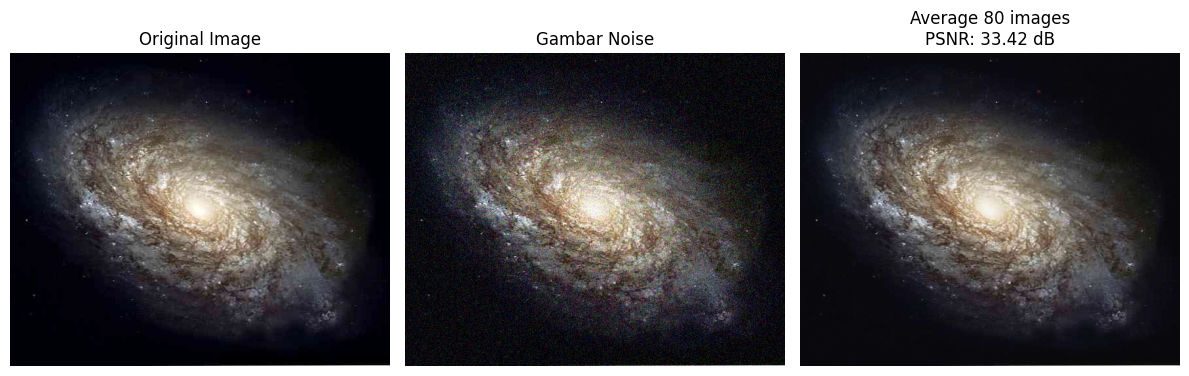

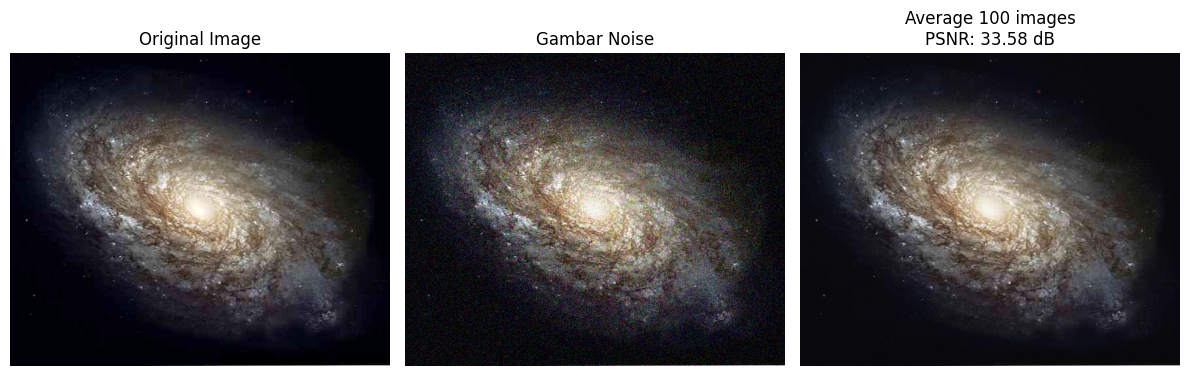


HASIL PSNR - AVERAGE DENOISING
Jumlah Citra | PSNR (dB) | Peningkatan Kualitas
--------------------------------------------------
           5 |    30.12 | 
          10 |    30.86 | (+0.73 dB)
          20 |    31.78 | (+0.93 dB)
          40 |    32.72 | (+0.94 dB)
          80 |    33.42 | (+0.70 dB)
         100 |    33.58 | (+0.16 dB)

KESIMPULAN:
Semakin banyak gambar yang dirata-ratakan, semakin tinggi nilai PSNR.
Peningkatan PSNR dari 5 ke 100 gambar: 3.46 dB
PSNR yang lebih tinggi menunjukkan kualitas gambar hasil denoising yang lebih baik


In [11]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
import matplotlib.pyplot as plt

def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)  # Menghitung Mean Squared Error
    if(mse == 0):
        return 100  # Jika MSE = 0, PSNR = tak hingga (diwakili 100)
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))  # Rumus PSNR
    return psnr

# Membaca gambar asli
original_img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/galaxy.jpg')
original_img = cv.cvtColor(original_img, cv.COLOR_BGR2RGB)

print(f"Original image shape: {original_img.shape}")

# PERBAIKAN: Path yang benar untuk membaca gambar noise
# Asumsikan gambar noise berada di folder '/content/noises/'
cv_img = []
noise_files = glob.glob('/content/drive/MyDrive/PCVK/JS5/Images/noises/*.jpg')  # Baca semua file jpg di folder noises

print(f"Found {len(noise_files)} noise images")

if len(noise_files) == 0:
    # JIKA TIDAK ADA GAMBAR NOISE, BUAT SIMULASI
    print("Creating simulated noise images...")
    for i in range(100):
        # Tambahkan Gaussian noise ke gambar asli
        noise = np.random.normal(0, 25, original_img.shape).astype(np.float32)
        noisy_img = original_img.astype(np.float32) + noise
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
        cv_img.append(noisy_img)
else:
    # Baca gambar noise yang ada
    for img_path in noise_files:
        n = cv.imread(img_path)
        n = cv.cvtColor(n, cv.COLOR_BGR2RGB)  # Konversi ke RGB
        cv_img.append(n)

print(f"Total images loaded: {len(cv_img)}")

# Pastikan kita punya cukup gambar untuk test
available_images = len(cv_img)
test_counts = [5, 10, 20, 40, 80, 100]
# Filter test_counts berdasarkan jumlah gambar yang tersedia
test_counts = [count for count in test_counts if count <= available_images]

if not test_counts:
    test_counts = [min(5, available_images)]  # Minimal test dengan 5 gambar

print(f"Testing with counts: {test_counts}")

results = []

for count in test_counts:
    # Average denoising
    avg_img = np.zeros_like(cv_img[0], dtype=np.float32)

    # PERBAIKAN: Pastikan tidak melebihi jumlah gambar yang ada
    actual_count = min(count, len(cv_img))

    for i in range(actual_count):
        avg_img += cv_img[i].astype(np.float32)

    avg_img = avg_img / actual_count  # Rata-rata pixel
    avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)  # Konversi ke integer dengan clip

    # Hitung PSNR
    psnr_value = PSNR(original_img, avg_img)
    results.append((actual_count, avg_img, psnr_value))

    # Tampilkan hasil
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Tampilkan salah satu gambar noise untuk perbandingan
    plt.imshow(cv_img[0])
    plt.title('Gambar Noise')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(avg_img)
    plt.title(f'Average {actual_count} images\nPSNR: {psnr_value:.2f} dB')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tampilkan tabel hasil
print("\n" + "="*50)
print("HASIL PSNR - AVERAGE DENOISING")
print("="*50)
print("Jumlah Citra | PSNR (dB) | Peningkatan Kualitas")
print("-" * 50)

# Urutkan hasil berdasarkan jumlah citra
results.sort(key=lambda x: x[0])

for i, (count, img, psnr) in enumerate(results):
    improvement = ""
    if i > 0:
        prev_psnr = results[i-1][2]
        improvement = f"(+{psnr-prev_psnr:.2f} dB)"
    print(f"{count:12} | {psnr:8.2f} | {improvement}")

# Kesimpulan
print("\n" + "="*50)
print("KESIMPULAN:")
print("="*50)
if len(results) > 1:
    first_psnr = results[0][2]
    last_psnr = results[-1][2]
    improvement_total = last_psnr - first_psnr
    print(f"Semakin banyak gambar yang dirata-ratakan, semakin tinggi nilai PSNR.")
    print(f"Peningkatan PSNR dari {results[0][0]} ke {results[-1][0]} gambar: {improvement_total:.2f} dB")
    print(f"PSNR yang lebih tinggi menunjukkan kualitas gambar hasil denoising yang lebih baik")
else:
    print(f"PSNR untuk {results[0][0]} gambar: {results[0][2]:.2f} dB")

**4. Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff), sedangkan image paling kanan adalah hasilnya.**

Ukuran gambar: 739 x 556


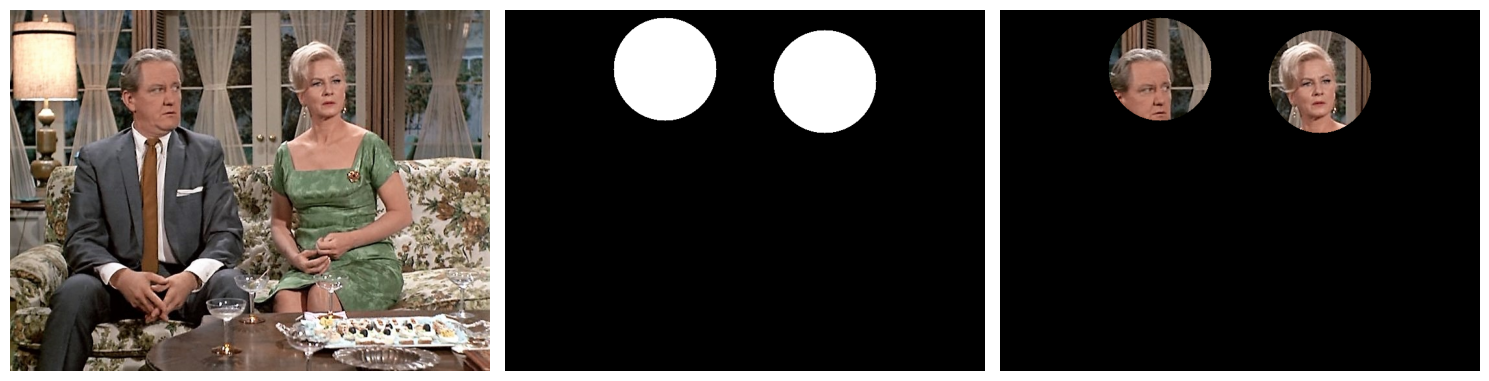

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/couple.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Membuat mask dengan 2 lingkaran putih di bagian atas (seperti mata)
mask = np.zeros(img.shape[:2], dtype=np.uint8)
height, width = img.shape[:2]

print(f"Ukuran gambar: {width} x {height}")

# Menyesuaikan posisi lingkaran agar tepat di wajah
# Lingkaran kiri (untuk wajah kiri)
center_left = (width // 3, height // 6)  # Posisi lebih ke bawah untuk wajah
radius = min(width, height) // 7  # Ukuran lingkaran lebih kecil

cv.circle(mask, center_left, radius, 255, -1)

# Lingkaran kanan (untuk wajah kanan)
center_right = (2 * width // 3, height // 5)  # Posisi lebih ke bawah untuk wajah
cv.circle(mask, center_right, radius, 255, -1)

# Apply masking dengan operator AND
masked_img = cv.bitwise_and(img, img, mask=mask)

# Menampilkan hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_img)
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan:**

- Gambar kiri (asli) → menampilkan citra pasangan lengkap tanpa perubahan.

- Gambar tengah (mask) → gambar hitam dengan 2 lingkaran putih di bagian atas (area wajah). Ini menunjukkan area yang akan diambil.

- Gambar kanan (hasil masking) → hanya bagian yang sesuai lingkaran putih pada mask yang terlihat dari gambar asli. Sisanya jadi hitam.

- Efeknya: seperti spotlight di wajah → hanya area lingkaran yang tampak, seluruh background hilang.

**Kesimpulan:**

- Masking ini menyoroti area tertentu dari gambar (dua wajah) dengan bentuk lingkaran.

- Operator AND menjaga pixel gambar asli hanya pada area mask putih, dan membuang area lain jadi hitam.

- Masking semacam ini sangat berguna untuk fokus pada ROI (Region of Interest), misalnya deteksi wajah, segmentasi objek, atau efek visual.